## Objectif

Identifier automatiquement différents comportements du marché à l'aide du machine learning non supervisé.

Le clustering permet de regrouper les observations similaires sans utiliser la variable cible.

Les clusters obtenus représentent différents régimes de marché :

- Marché haussier
- Marché baissier
- Marché volatil
- Marché en consolidation

# 2. Importation des bibliothèques

In [14]:
from pathlib import Path
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 3. Chargement des données

In [21]:
## Chargement des données enrichies
PROJECT_ROOT = Path.cwd().parent

FEATURES_DIR = PROJECT_ROOT / "data" / "features"

gold = pd.read_csv(
    FEATURES_DIR / "gold_features.csv"
)

silver = pd.read_csv(
    FEATURES_DIR / "silver_features.csv"
)

display(gold.head())

,Datetime,Close,High,Low,Open,Volume,Ticker,EMA20,EMA50,RSI,ATR,Target,EMA200,Return,Volatility,Market_Regime,Hour,DayOfWeek,Timeframe
0,2024-05-31 01:00:00+00:00,2367.899902,2368.800049,2344.800049,2367.500000,3302,GC=F,2363.060853,2360.692465,57.070461,28.528582,0,2359.151629,0.000127,0.002981,Bull,1,4,H1
1,2024-05-31 02:00:00+00:00,2363.899902,2369.000000,2342.000000,2367.800049,2571,GC=F,2363.150699,2360.907379,58.701180,28.428571,0,2359.390873,-0.001689,0.002810,Bull,2,4,H1
2,2024-05-31 03:00:00+00:00,2364.100098,2364.699951,2338.800049,2363.800049,5985,GC=F,2363.251172,2361.115523,51.963800,27.671422,1,2359.618928,0.000085,0.002747,Bull,3,4,H1
3,2024-05-31 04:00:00+00:00,2365.100098,2366.899902,2342.899902,2364.800049,3149,GC=F,2363.444790,2361.368713,40.225781,27.057129,0,2359.874531,0.000423,0.001563,Bull,4,4,H1
4,2024-05-31 05:00:00+00:00,2363.500000,2365.600098,2341.000000,2365.000000,2597,GC=F,2363.450517,2361.500924,45.726567,26.478568,1,2360.037615,-0.000677,0.001575,Bull,5,4,H1


## 4. Sélection des variables

## Variables utilisées pour le clustering

Les variables sélectionnées représentent :

- Momentum
- Volatilité
- Rendement
- Comportement du marché

In [22]:
cluster_features = [
    "RSI",
    "ATR",
    "Return",
    "Volatility"
]

## 5. Normalisation des données

K-Means fonctionne mieux lorsque les variables sont sur la même échelle.

In [23]:
scaler = StandardScaler()

X_gold = scaler.fit_transform(
    gold[cluster_features]
)

## 6 Création du modèle de clustering

In [24]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

gold["Cluster"] = kmeans.fit_predict(
    X_gold
)

## 7. Distribution des clusters

In [25]:
gold["Cluster"].value_counts()

Cluster
0    4803
2    4383
1    2092
3     125
Name: count, dtype: int64

## Interprétation

Les clusters représentent différents régimes de marché.

Exemple :

- Cluster 0 : Marché calme
- Cluster 1 : Forte tendance haussière
- Cluster 2 : Forte tendance baissière
- Cluster 3 : Forte volatilité

L'interprétation finale sera déterminée à partir des statistiques observées.

## 9.  Sauvegarde des données enrichies

In [26]:
CLUSTER_DIR = PROJECT_ROOT / "data" / "clustered"

CLUSTER_DIR.mkdir(exist_ok=True)

gold.to_csv(
    CLUSTER_DIR / "gold_clustered.csv",
    index=False
)

silver.to_csv(
    CLUSTER_DIR / "silver_clustered.csv",
    index=False
)

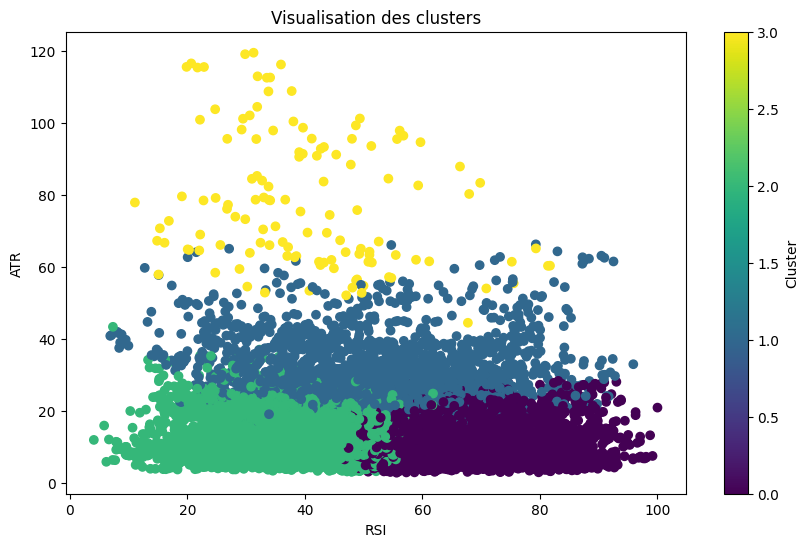

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    gold["RSI"],
    gold["ATR"],
    c=gold["Cluster"]
)

plt.xlabel("RSI")
plt.ylabel("ATR")
plt.title("Visualisation des clusters")
plt.colorbar(label="Cluster")

plt.show()

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_gold)

gold["PCA1"] = X_pca[:,0]
gold["PCA2"] = X_pca[:,1]

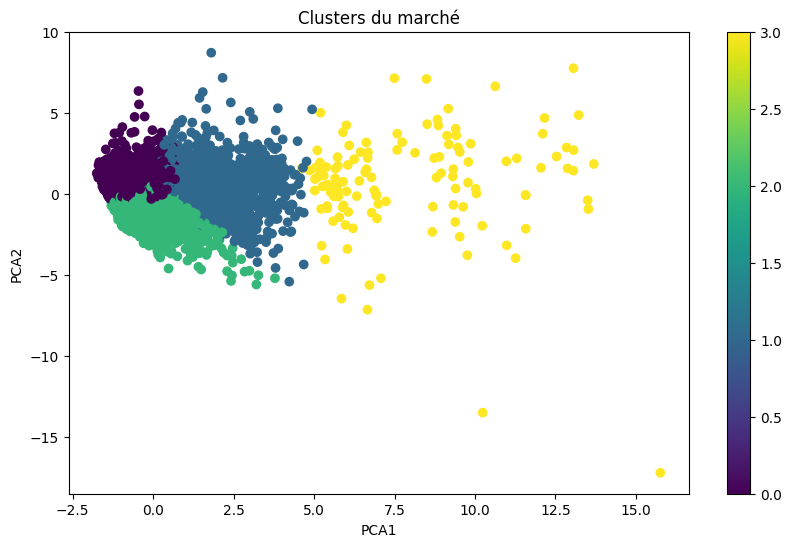

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(
    gold["PCA1"],
    gold["PCA2"],
    c=gold["Cluster"]
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Clusters du marché")
plt.colorbar()

plt.show()